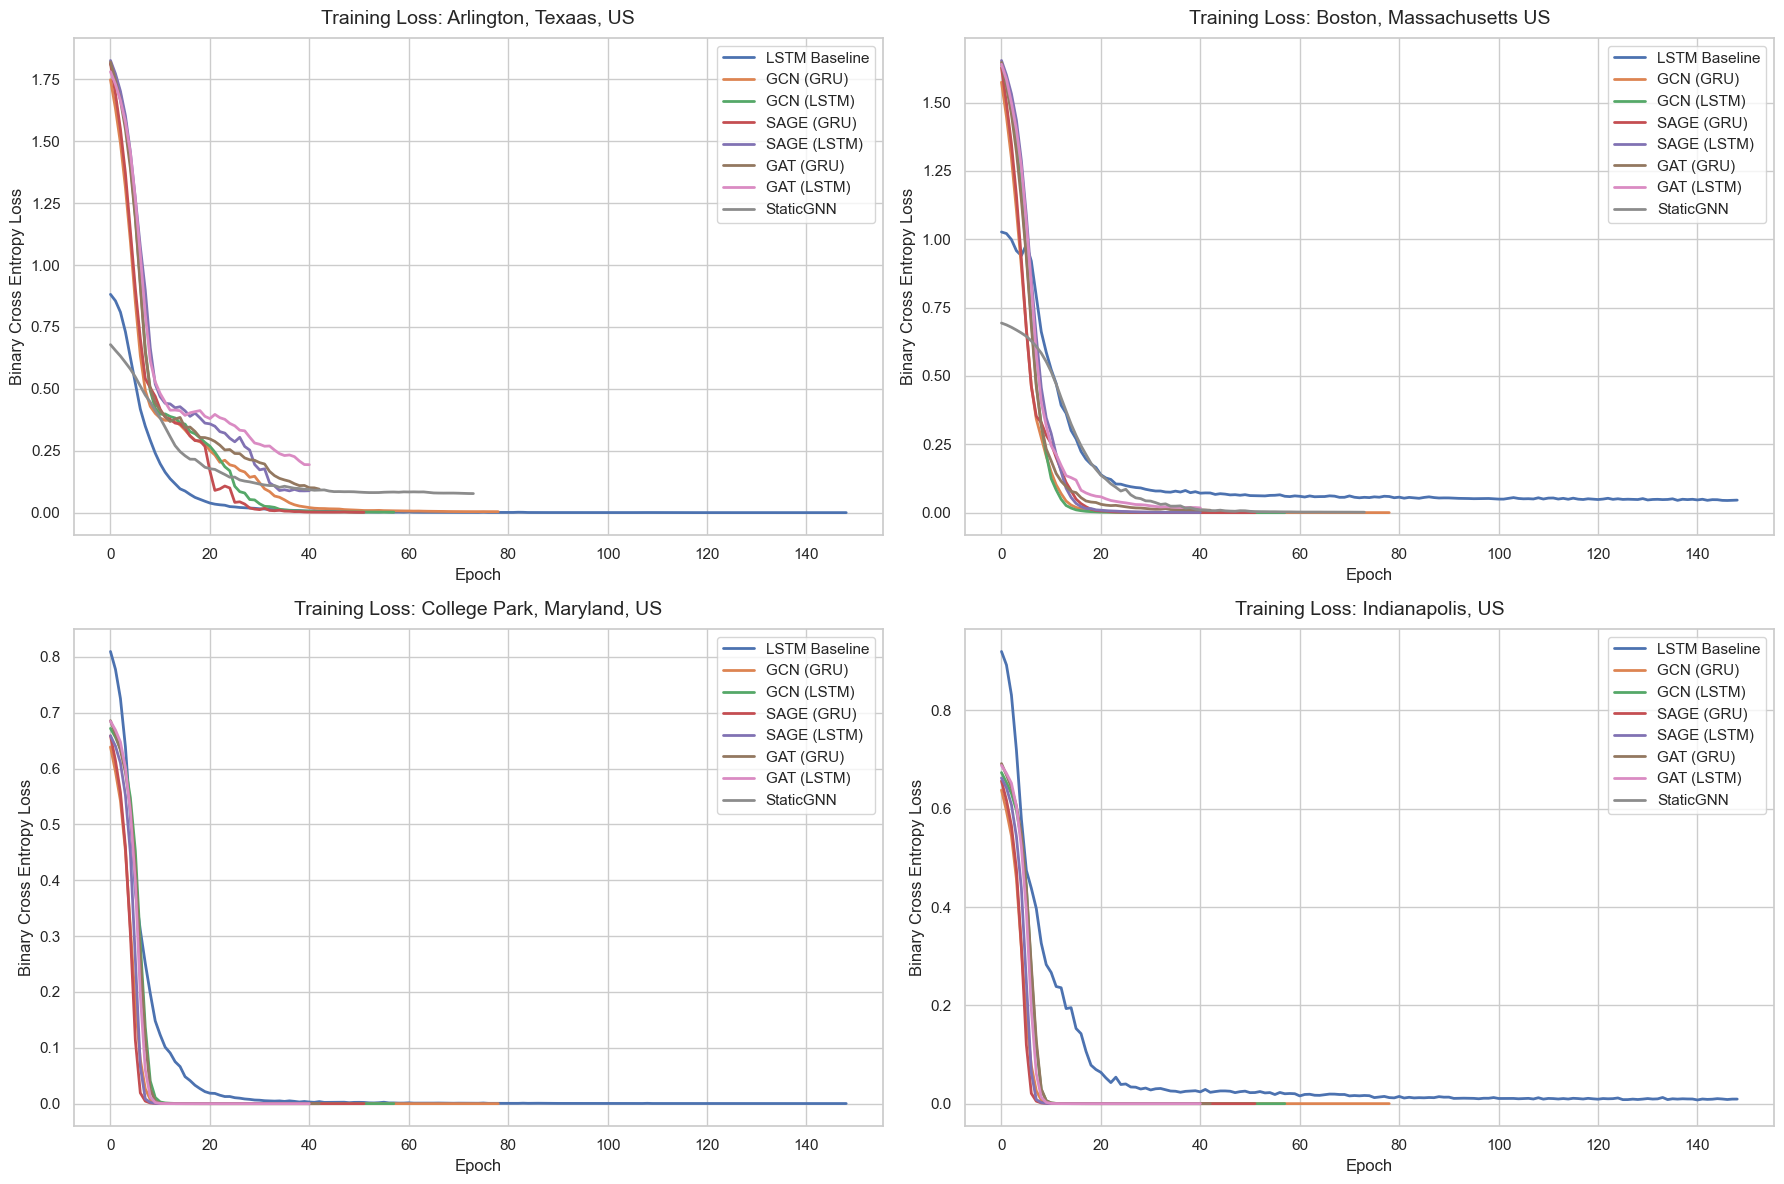

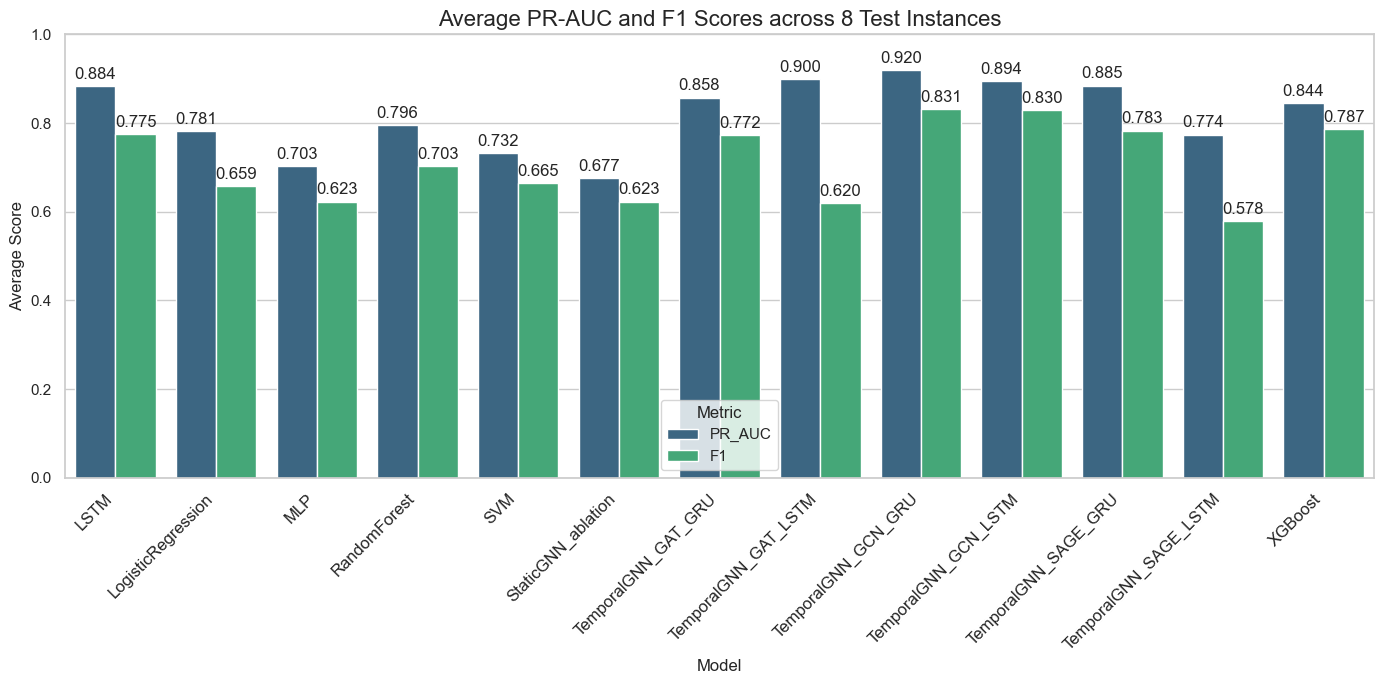

In [ ]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

metrics_dir = "outputs/metrics"

def get_latest_file(pattern):
    """Utility to quickly grab the most recently generated Excel file for a pattern."""
    files = glob.glob(os.path.join(metrics_dir, pattern))
    if not files: return None
    return max(files, key=os.path.getctime)

# =========================================================
# 1. Plot Training Loss Curves (LSTM vs GNN Variants)
# =========================================================
train_files = {
    "LSTM_MLP": get_latest_file("lstm_train_curves_*.xlsx"),
    "TGCN_GRU_MLP": get_latest_file("TemporalGNN_GCN_GRU_train_curves_*.xlsx"),
    "TGCN_LSTM": get_latest_file("TemporalGNN_GCN_LSTM_train_curves_*.xlsx"),
    "TSAGE_GRU_MLP": get_latest_file("TemporalGNN_SAGE_GRU_train_curves_*.xlsx"),
    "TSAGE_LSTM_MLP": get_latest_file("TemporalGNN_SAGE_LSTM_train_curves_*.xlsx"),
    "TGAT_GRU_MLP": get_latest_file("TemporalGNN_GSAT_GRU_train_curves_*.xlsx"),
    "TGAT_LSTM_MLP": get_latest_file("TemporalGNN_GAT_LSTM_train_curves_*.xlsx"),
    "GCN_MLP": get_latest_file("StaticGNN_ablation_train_curves_*.xlsx")
}

# The 4 training areas we dynamically split during training
areas = ['Arlington, Texaas, US', 'Boston, Massachusetts US', 
         'College Park, Maryland, US', 'Indianapolis, US']

plt.figure(figsize=(18, 12))
sns.set_theme(style="whitegrid")

for i, area in enumerate(areas, 1):
    plt.subplot(2, 2, i)
    for model_name, file_path in train_files.items():
        if file_path:
            df = pd.read_excel(file_path)
            col_name = f"{area}_Train_Loss"
            if col_name in df.columns:
                # Plot the training epoch convergence
                plt.plot(df['Epoch'], df[col_name], label=model_name, linewidth=2)
    
    plt.title(f"Training Loss: {area}", fontsize=14, pad=10)
    plt.xlabel("Epoch", fontsize=12)
    plt.ylabel("Binary Cross Entropy Loss", fontsize=12)
    plt.legend()

plt.tight_layout()
plt.show()

# =========================================================
# 2. Compare Average Test Metrics (All Models)
# =========================================================
test_files = [
    get_latest_file("lstm_test_metrics_*.xlsx"),
    get_latest_file("TemporalGNN_GCN_GRU_test_metrics_*.xlsx"),
    get_latest_file("TemporalGNN_GCN_LSTM_test_metrics_*.xlsx"),
    get_latest_file("TemporalGNN_SAGE_GRU_test_metrics_*.xlsx"),
    get_latest_file("TemporalGNN_SAGE_LSTM_test_metrics_*.xlsx"),
    get_latest_file("TemporalGNN_GAT_GRU_test_metrics_*.xlsx"),
    get_latest_file("TemporalGNN_GAT_LSTM_test_metrics_*.xlsx"),
    get_latest_file("StaticGNN_ablation_test_metrics_*.xlsx"),
    get_latest_file("tabular_test_metrics_*.xlsx")
]

test_dfs = []
for f in test_files:
    if f:
        test_dfs.append(pd.read_excel(f))

if test_dfs:
    combined_test = pd.concat(test_dfs, ignore_index=True)
    
    # Calculate global average metrics across the 8 unseen prediction regions
    avg_metrics = combined_test.groupby('Model')[['PR_AUC', 'F1']].mean().reset_index()
    
    # Melt dataframe for easy Seaborn grouped bar charting
    melted = avg_metrics.melt(id_vars='Model', var_name='Metric', value_name='Score')
    
    plt.figure(figsize=(14, 7))
    ax = sns.barplot(data=melted, x='Model', y='Score', hue='Metric', palette='viridis')
    plt.title('Average PR-AUC and F1 Scores across 8 Test Instances', fontsize=16)
    plt.ylim(0, 1.0)
    plt.xticks(rotation=45, ha='right', fontsize=12)
    plt.ylabel("Average Score", fontsize=12)
    plt.legend(title='Metric')
    
    # Add score annotations above each bar
    for i in ax.containers:
        ax.bar_label(i, fmt='%.3f', padding=3)

    plt.tight_layout()
    plt.show()
else:
    print("No test metric datasets found.")


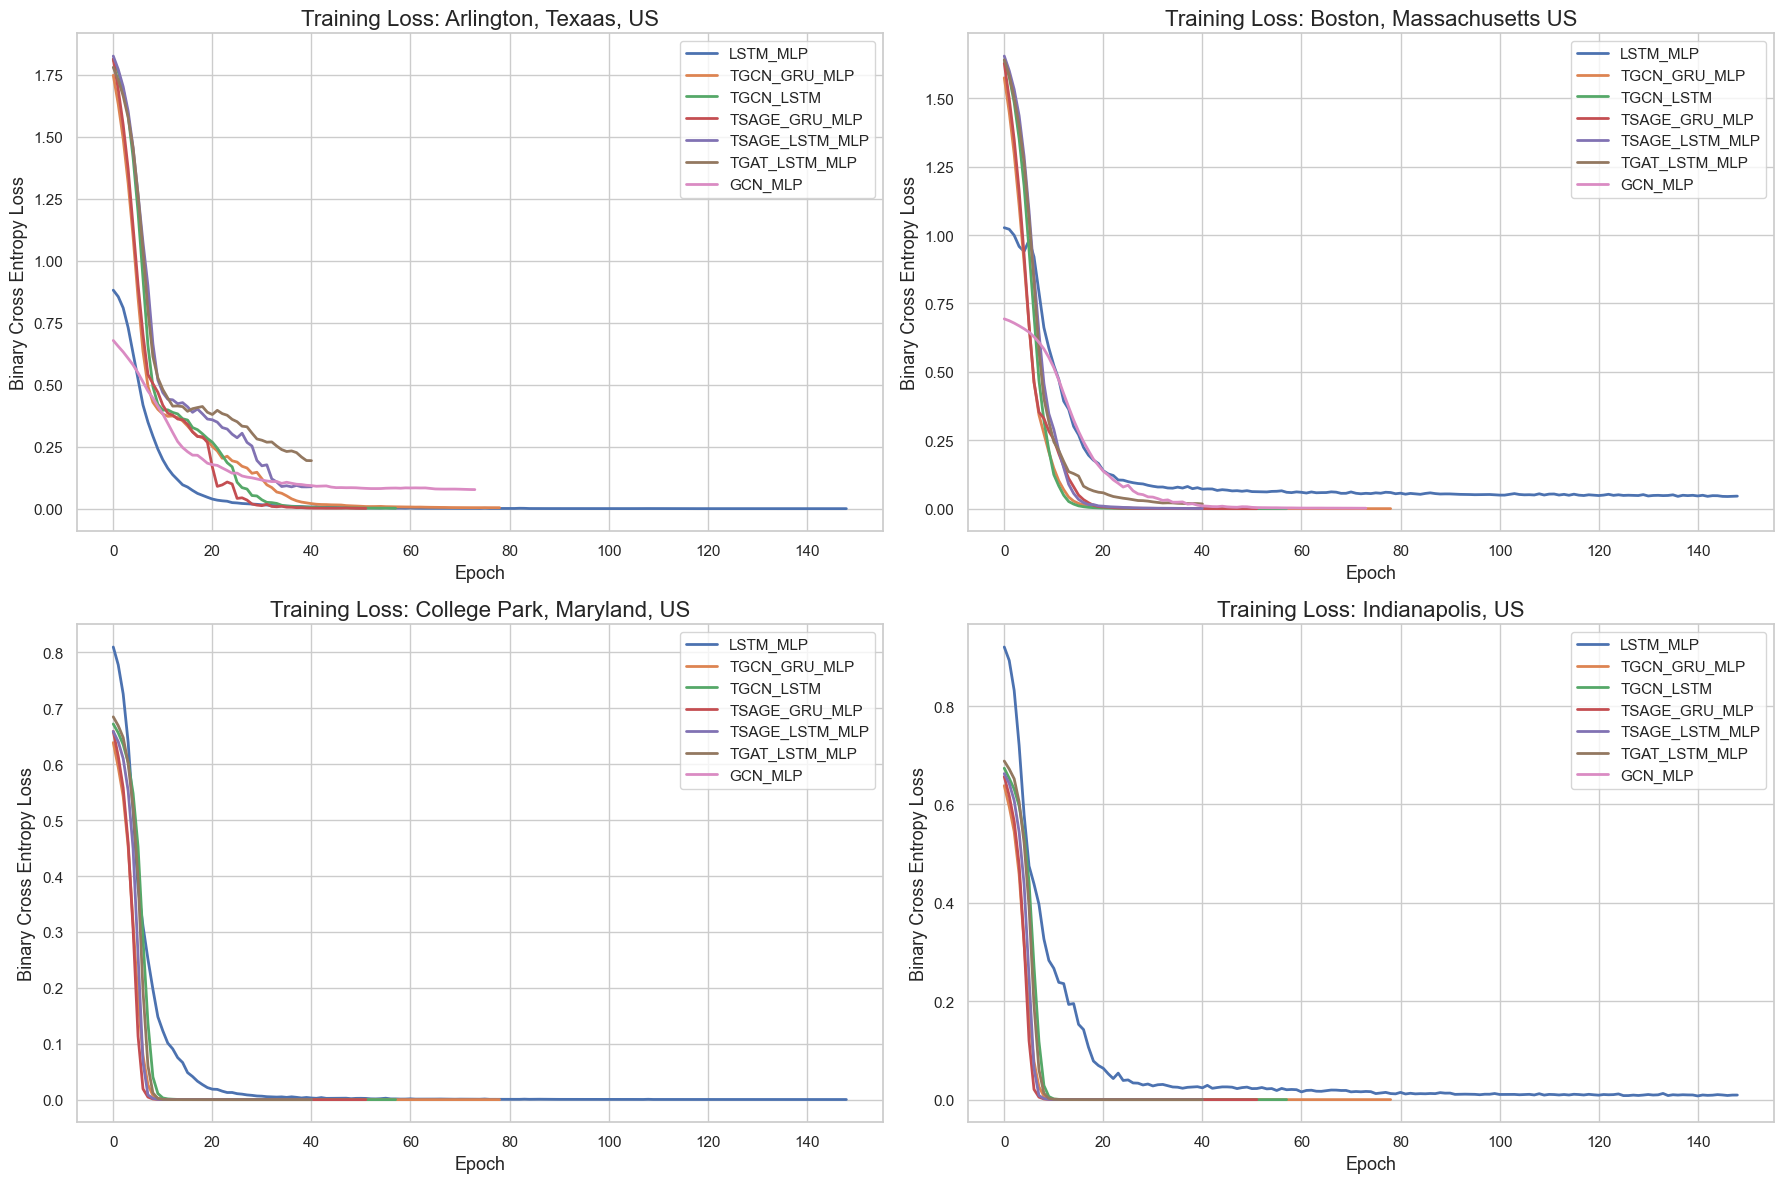

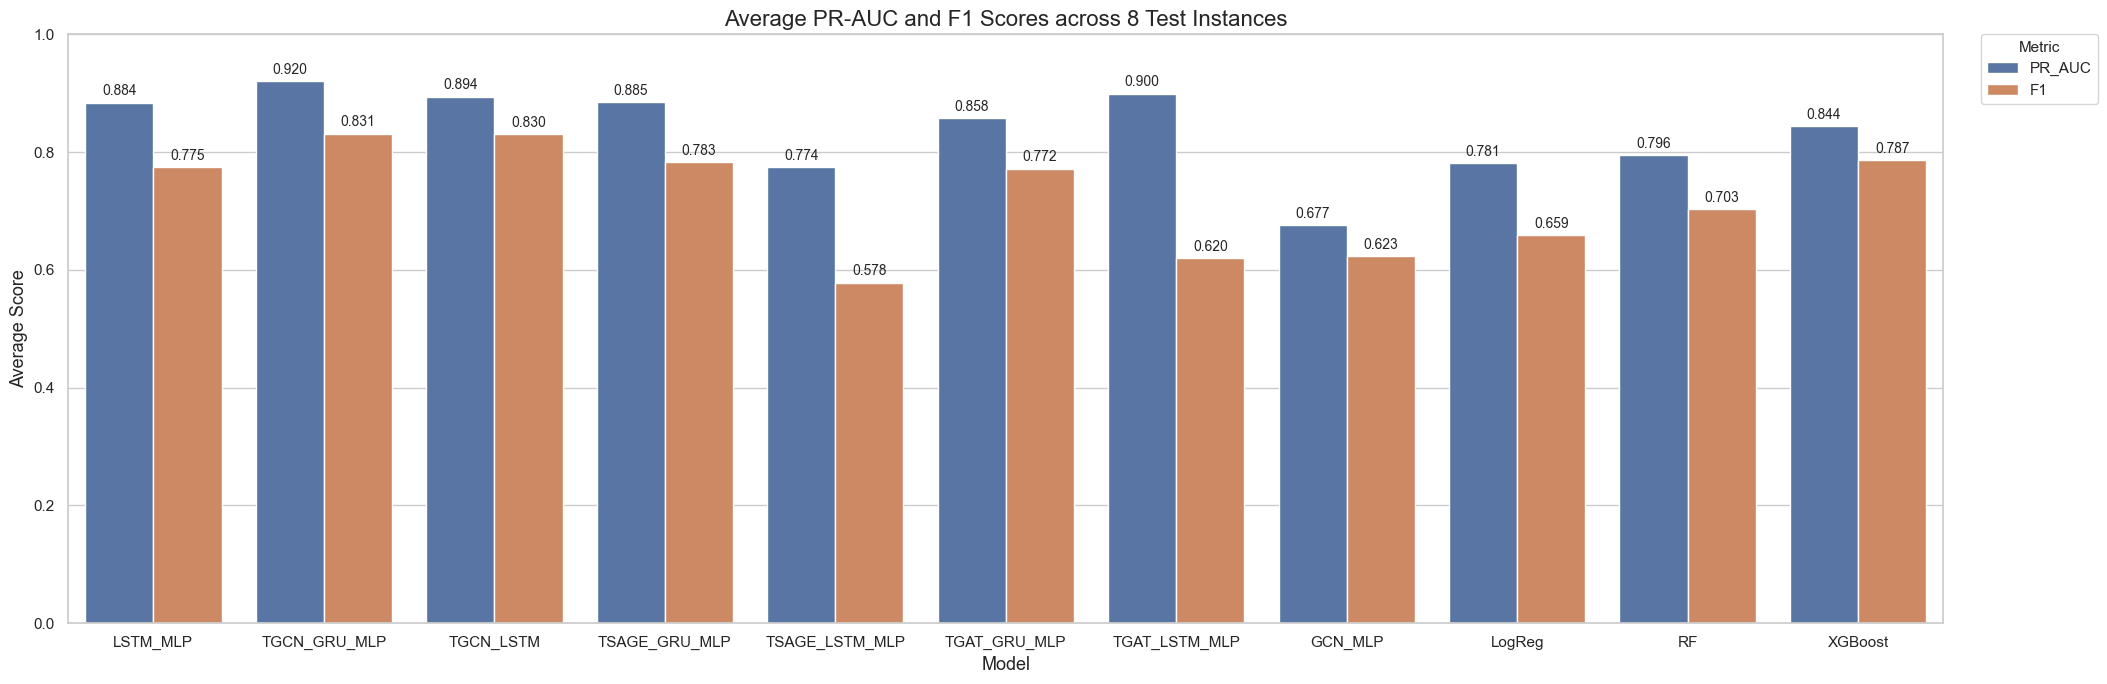

In [ ]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

metrics_dir = "outputs/metrics"

def get_latest_file(pattern):
    files = glob.glob(os.path.join(metrics_dir, pattern))
    if not files:
        return None
    return max(files, key=os.path.getctime)

# ================= COMMON STYLE =================
sns.set_theme(style="whitegrid")

TITLE_FSIZE = 16
LABEL_FSIZE = 13
LEGEND_FSIZE = 11

def style_legend(ax, loc="best"):
    ax.legend(
        # title="Model / Metric",
        fontsize=LEGEND_FSIZE,
        title_fontsize=LEGEND_FSIZE,
        loc=loc,
        frameon=True
    )

# =========================================================
# 1. Plot Training Loss Curves (LSTM vs GNN Variants)
# =========================================================
train_files = {
    "LSTM_MLP": get_latest_file("lstm_train_curves_*.xlsx"),
    "TGCN_GRU_MLP": get_latest_file("TemporalGNN_GCN_GRU_train_curves_*.xlsx"),
    "TGCN_LSTM": get_latest_file("TemporalGNN_GCN_LSTM_train_curves_*.xlsx"),
    "TSAGE_GRU_MLP": get_latest_file("TemporalGNN_SAGE_GRU_train_curves_*.xlsx"),
    "TSAGE_LSTM_MLP": get_latest_file("TemporalGNN_SAGE_LSTM_train_curves_*.xlsx"),
    "TGAT_GRU_MLP": get_latest_file("TemporalGNN_GSAT_GRU_train_curves_*.xlsx"),
    "TGAT_LSTM_MLP": get_latest_file("TemporalGNN_GAT_LSTM_train_curves_*.xlsx"),
    "GCN_MLP": get_latest_file("StaticGNN_ablation_train_curves_*.xlsx")
}



areas = [
    'Arlington, Texaas, US',
    'Boston, Massachusetts US',
    'College Park, Maryland, US',
    'Indianapolis, US'
]

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

for ax, area in zip(axes.flatten(), areas):
    for model_name, file_path in train_files.items():
        if file_path:
            df = pd.read_excel(file_path)
            col_name = f"{area}_Train_Loss"
            if col_name in df.columns:
                ax.plot(df['Epoch'], df[col_name], label=model_name, linewidth=2)

    ax.set_title(f"Training Loss: {area}", fontsize=TITLE_FSIZE)
    ax.set_xlabel("Epoch", fontsize=LABEL_FSIZE)
    ax.set_ylabel("Binary Cross Entropy Loss", fontsize=LABEL_FSIZE)
    style_legend(ax, loc="best")

plt.tight_layout()
plt.show()

# =========================================================
# 2. Compare Average Test Metrics (All Models)
# =========================================================
test_files = [
    get_latest_file("lstm_test_metrics_*.xlsx"),
    get_latest_file("StaticGNN_ablation_test_metrics_*.xlsx"),
    get_latest_file("tabular_test_metrics_*.xlsx"),
    get_latest_file("TemporalGNN_GCN_GRU_test_metrics_*.xlsx"),
    get_latest_file("TemporalGNN_GCN_LSTM_test_metrics_*.xlsx"),
    get_latest_file("TemporalGNN_SAGE_GRU_test_metrics_*.xlsx"),
    get_latest_file("TemporalGNN_SAGE_LSTM_test_metrics_*.xlsx"),
    get_latest_file("TemporalGNN_GAT_GRU_test_metrics_*.xlsx"),
    get_latest_file("TemporalGNN_GAT_LSTM_test_metrics_*.xlsx"),
]

MODEL_NAME_MAP = {
    "LSTM": "LSTM_MLP",
    "LogisticRegression": "LogReg",
    "MLP": "MLP",
    "RandomForest": "RF",
    "SVM": "SVM",
    "StaticGNN_ablation": "GCN_MLP",
    "TemporalGNN_GAT_GRU": "TGAT_GRU_MLP",
    "TemporalGNN_GAT_LSTM": "TGAT_LSTM_MLP",
    "TemporalGNN_GCN_GRU": "TGCN_GRU_MLP",
    "TemporalGNN_GCN_LSTM": "TGCN_LSTM",
    "TemporalGNN_SAGE_GRU": "TSAGE_GRU_MLP",
    "TemporalGNN_SAGE_LSTM": "TSAGE_LSTM_MLP",
    "XGBoost": "XGBoost"
}

test_dfs = []
for f in test_files:
    if f:
        test_dfs.append(pd.read_excel(f))

if test_dfs:
    combined_test = pd.concat(test_dfs, ignore_index=True)

    # 🔥 Apply consistent naming
    combined_test['Model'] = combined_test['Model'].map(MODEL_NAME_MAP).fillna(combined_test['Model'])

    avg_metrics = combined_test.groupby('Model')[['PR_AUC', 'F1']].mean().reset_index()

    # 🔥 Optional: enforce same order as training plots
    model_order = list(train_files.keys()) + ["LogReg", "RF", "XGBoost"]
    avg_metrics['Model'] = pd.Categorical(avg_metrics['Model'], categories=model_order, ordered=True)
    avg_metrics = avg_metrics.sort_values('Model')

    melted = avg_metrics.melt(id_vars='Model', var_name='Metric', value_name='Score')

    fig, ax = plt.subplots(figsize=(25, 7))  # slightly wider

    sns.barplot(data=melted, x='Model', y='Score', hue='Metric', ax=ax)

    ax.set_title('Average PR-AUC and F1 Scores across 8 Test Instances', fontsize=TITLE_FSIZE)
    ax.set_xlabel("Model", fontsize=LABEL_FSIZE)
    ax.set_ylabel("Average Score", fontsize=LABEL_FSIZE)
    ax.set_ylim(0, 1.0)

    # ✅ FIX 1: Horizontal labels (no rotation)
    ax.tick_params(axis='x', rotation=0, labelsize=11)

    # ✅ FIX 2: Legend OUTSIDE (cleanest for papers)
    ax.legend(
        title='Metric',
        fontsize=LEGEND_FSIZE,
        title_fontsize=LEGEND_FSIZE,
        loc='upper left',
        bbox_to_anchor=(1.02, 1),  # push outside
        borderaxespad=0.
    )

    # annotations
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', padding=3, fontsize=10)

    # ✅ important: leave space for legend
    plt.tight_layout(rect=[0, 0, 0.85, 1])

    plt.show()

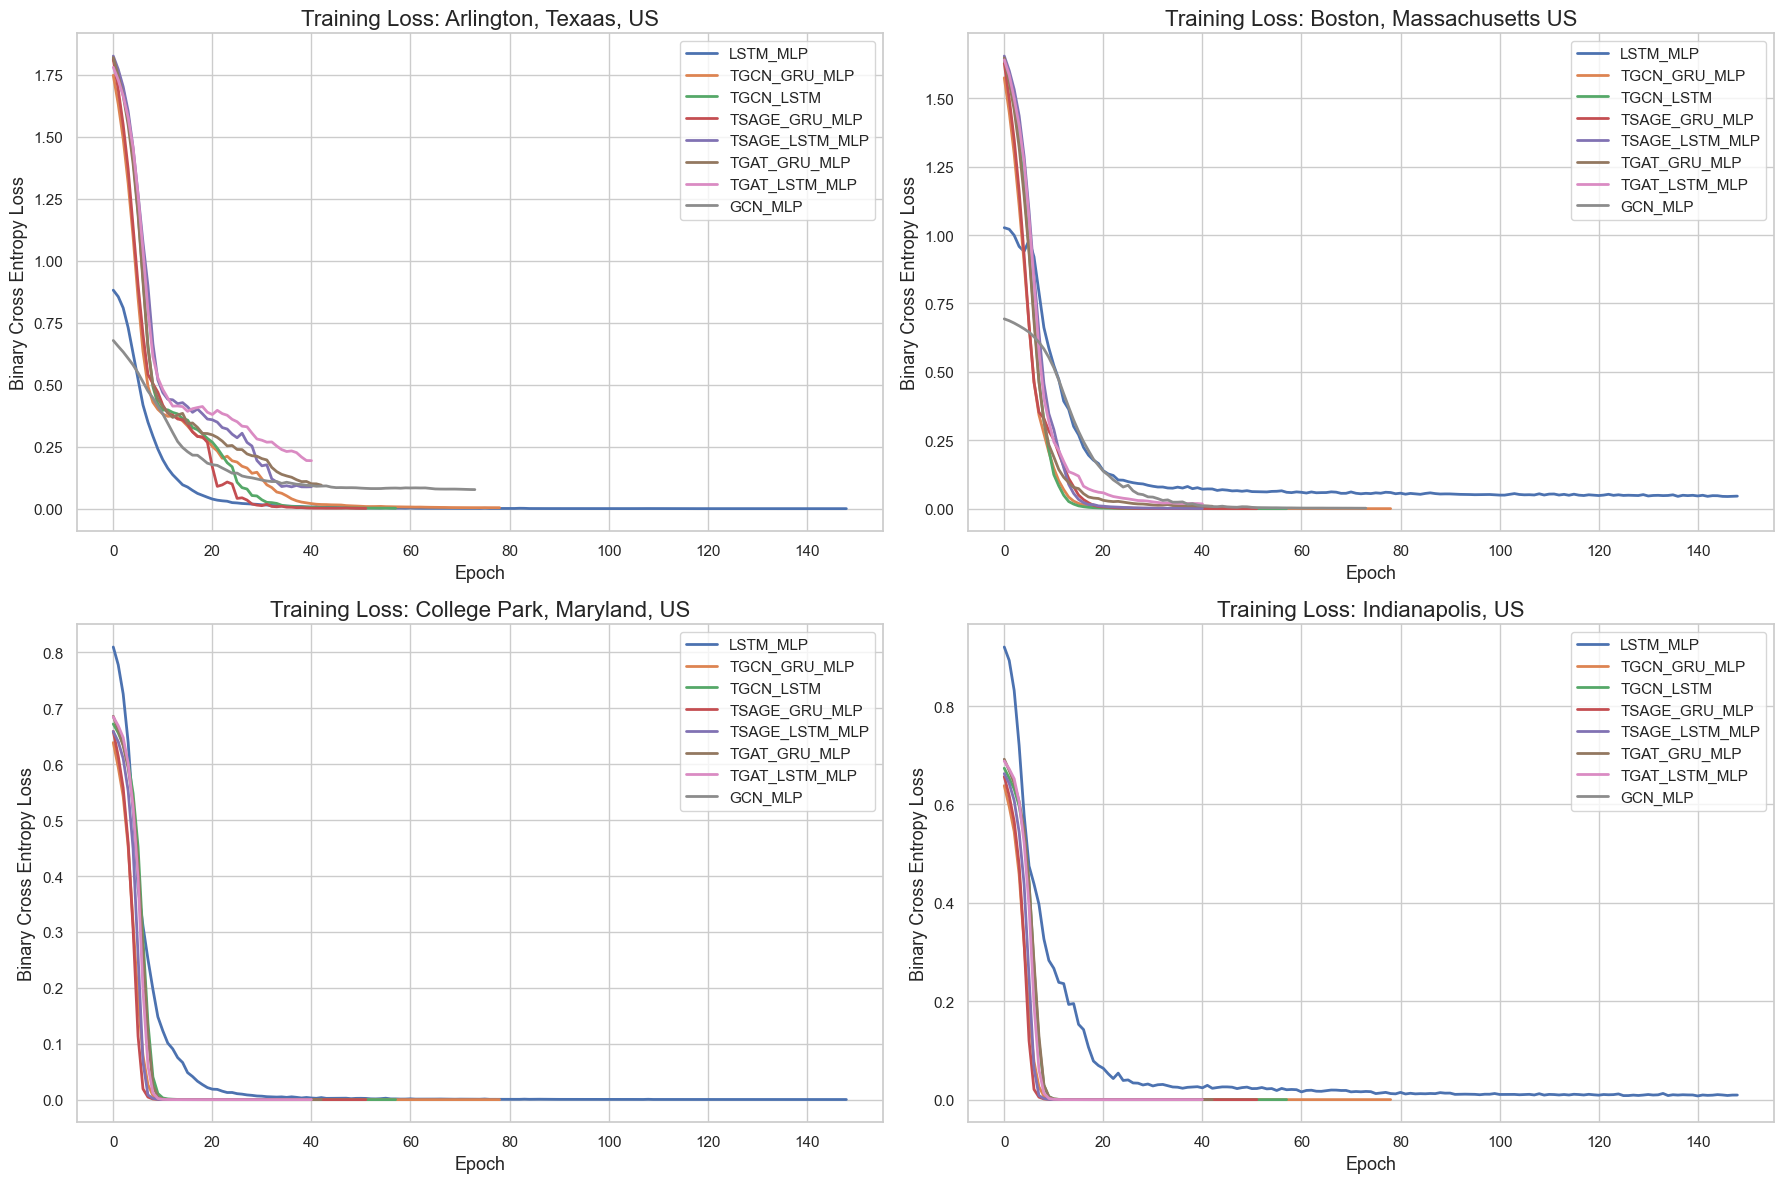


SUMMARY OF TEST PERFORMANCE ACROSS INSTANCES
         Model PR_AUC (mean ± std) F1 (mean ± std)
      LSTM_MLP     0.8841 ± 0.0833 0.7749 ± 0.0937
  TGCN_GRU_MLP     0.9201 ± 0.0930 0.8315 ± 0.1490
     TGCN_LSTM     0.8945 ± 0.0938 0.8301 ± 0.0588
 TSAGE_GRU_MLP     0.8848 ± 0.1620 0.7831 ± 0.1907
TSAGE_LSTM_MLP     0.7740 ± 0.2617 0.5784 ± 0.2093
  TGAT_GRU_MLP     0.8575 ± 0.1842 0.7721 ± 0.2172
 TGAT_LSTM_MLP     0.8996 ± 0.1181 0.6200 ± 0.1057
       GCN_MLP     0.6768 ± 0.1150 0.6228 ± 0.0534
        LogReg     0.7814 ± 0.0896 0.6586 ± 0.1222
           MLP     0.7026 ± 0.1518 0.6232 ± 0.0987
            RF     0.7956 ± 0.1599 0.7028 ± 0.1672
           SVM     0.7322 ± 0.1206 0.6647 ± 0.1425
       XGBoost     0.8444 ± 0.1019 0.7869 ± 0.1120

Best PR-AUC model:
  TGCN_GRU_MLP: 0.9201 ± 0.0930
Best F1 model:
  TGCN_GRU_MLP: 0.8315 ± 0.1490


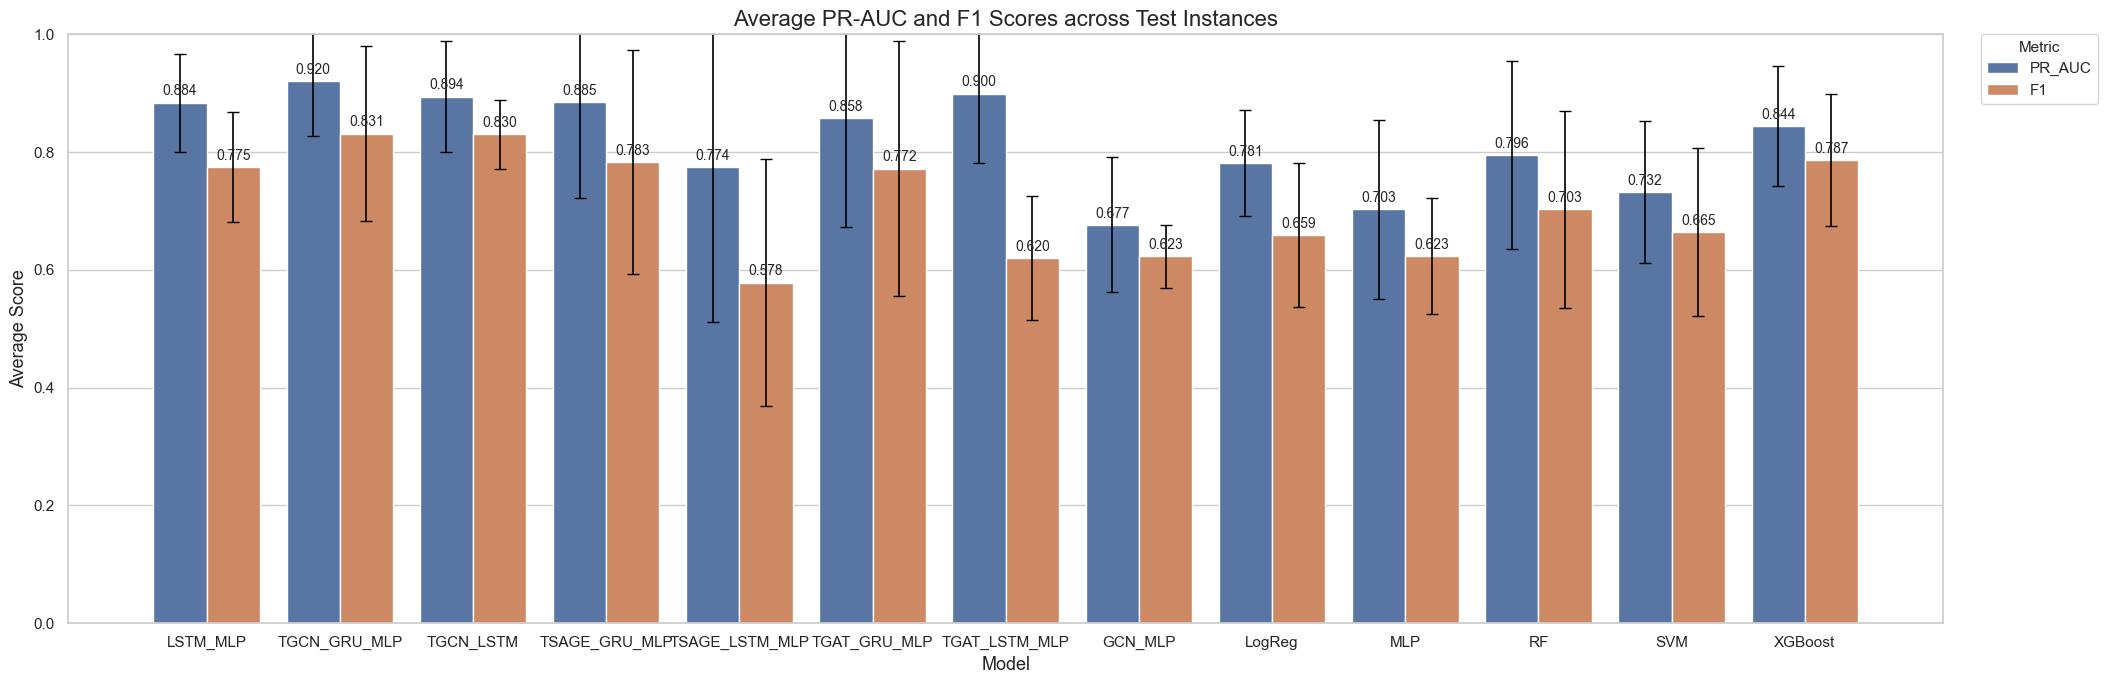

In [15]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

metrics_dir = "outputs/metrics"

def get_latest_file(pattern):
    files = glob.glob(os.path.join(metrics_dir, pattern))
    if not files:
        return None
    return max(files, key=os.path.getctime)

# ================= COMMON STYLE =================
sns.set_theme(style="whitegrid")

TITLE_FSIZE = 16
LABEL_FSIZE = 13
LEGEND_FSIZE = 11

def style_legend(ax, loc="best"):
    ax.legend(
        fontsize=LEGEND_FSIZE,
        title_fontsize=LEGEND_FSIZE,
        loc=loc,
        frameon=True
    )

# =========================================================
# 1. Plot Training Loss Curves (LSTM vs GNN Variants)
# =========================================================
train_files = {
    "LSTM_MLP": get_latest_file("lstm_train_curves_*.xlsx"),
    "TGCN_GRU_MLP": get_latest_file("TemporalGNN_GCN_GRU_train_curves_*.xlsx"),
    "TGCN_LSTM": get_latest_file("TemporalGNN_GCN_LSTM_train_curves_*.xlsx"),
    "TSAGE_GRU_MLP": get_latest_file("TemporalGNN_SAGE_GRU_train_curves_*.xlsx"),
    "TSAGE_LSTM_MLP": get_latest_file("TemporalGNN_SAGE_LSTM_train_curves_*.xlsx"),
    "TGAT_GRU_MLP": get_latest_file("TemporalGNN_GAT_GRU_train_curves_*.xlsx"),
    "TGAT_LSTM_MLP": get_latest_file("TemporalGNN_GAT_LSTM_train_curves_*.xlsx"),
    "GCN_MLP": get_latest_file("StaticGNN_ablation_train_curves_*.xlsx")
}

areas = [
    'Arlington, Texaas, US',
    'Boston, Massachusetts US',
    'College Park, Maryland, US',
    'Indianapolis, US'
]

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

for ax, area in zip(axes.flatten(), areas):
    for model_name, file_path in train_files.items():
        if file_path:
            df = pd.read_excel(file_path)
            col_name = f"{area}_Train_Loss"
            if col_name in df.columns:
                ax.plot(df['Epoch'], df[col_name], label=model_name, linewidth=2)

    ax.set_title(f"Training Loss: {area}", fontsize=TITLE_FSIZE)
    ax.set_xlabel("Epoch", fontsize=LABEL_FSIZE)
    ax.set_ylabel("Binary Cross Entropy Loss", fontsize=LABEL_FSIZE)
    style_legend(ax, loc="best")

plt.tight_layout()
plt.show()

# =========================================================
# 2. Compare Average Test Metrics (All Models) with Mean/Std
# =========================================================
test_files = [
    get_latest_file("lstm_test_metrics_*.xlsx"),
    get_latest_file("StaticGNN_ablation_test_metrics_*.xlsx"),
    get_latest_file("tabular_test_metrics_*.xlsx"),
    get_latest_file("TemporalGNN_GCN_GRU_test_metrics_*.xlsx"),
    get_latest_file("TemporalGNN_GCN_LSTM_test_metrics_*.xlsx"),
    get_latest_file("TemporalGNN_SAGE_GRU_test_metrics_*.xlsx"),
    get_latest_file("TemporalGNN_SAGE_LSTM_test_metrics_*.xlsx"),
    get_latest_file("TemporalGNN_GAT_GRU_test_metrics_*.xlsx"),
    get_latest_file("TemporalGNN_GAT_LSTM_test_metrics_*.xlsx"),
]

MODEL_NAME_MAP = {
    "LSTM": "LSTM_MLP",
    "LogisticRegression": "LogReg",
    "MLP": "MLP",
    "RandomForest": "RF",
    "SVM": "SVM",
    "StaticGNN_ablation": "GCN_MLP",
    "TemporalGNN_GAT_GRU": "TGAT_GRU_MLP",
    "TemporalGNN_GAT_LSTM": "TGAT_LSTM_MLP",
    "TemporalGNN_GCN_GRU": "TGCN_GRU_MLP",
    "TemporalGNN_GCN_LSTM": "TGCN_LSTM",
    "TemporalGNN_SAGE_GRU": "TSAGE_GRU_MLP",
    "TemporalGNN_SAGE_LSTM": "TSAGE_LSTM_MLP",
    "XGBoost": "XGBoost"
}

test_dfs = []
for f in test_files:
    if f:
        test_dfs.append(pd.read_excel(f))

if test_dfs:
    combined_test = pd.concat(test_dfs, ignore_index=True)

    # Consistent naming
    combined_test['Model'] = combined_test['Model'].map(MODEL_NAME_MAP).fillna(combined_test['Model'])

    # Keep only needed columns
    metric_cols = ['PR_AUC', 'F1']
    combined_test = combined_test[['Model'] + metric_cols].copy()

    # Mean and std per model
    summary_stats = (
        combined_test
        .groupby('Model')[metric_cols]
        .agg(['mean', 'std'])
        .reset_index()
    )

    # Flatten multi-index columns
    summary_stats.columns = [
        'Model',
        'PR_AUC_mean', 'PR_AUC_std',
        'F1_mean', 'F1_std'
    ]

    # Optional: order models consistently
    model_order = list(train_files.keys()) + ["LogReg", "MLP", "RF", "SVM", "XGBoost"]
    summary_stats['Model'] = pd.Categorical(summary_stats['Model'], categories=model_order, ordered=True)
    summary_stats = summary_stats.sort_values('Model')

    # -------- PRINT SUMMARY --------
    print("\n" + "=" * 90)
    print("SUMMARY OF TEST PERFORMANCE ACROSS INSTANCES")
    print("=" * 90)

    printable_summary = summary_stats.copy()
    printable_summary['PR_AUC (mean ± std)'] = printable_summary.apply(
        lambda row: f"{row['PR_AUC_mean']:.4f} ± {row['PR_AUC_std']:.4f}" if pd.notna(row['PR_AUC_std']) else f"{row['PR_AUC_mean']:.4f} ± 0.0000",
        axis=1
    )
    printable_summary['F1 (mean ± std)'] = printable_summary.apply(
        lambda row: f"{row['F1_mean']:.4f} ± {row['F1_std']:.4f}" if pd.notna(row['F1_std']) else f"{row['F1_mean']:.4f} ± 0.0000",
        axis=1
    )

    print(
        printable_summary[['Model', 'PR_AUC (mean ± std)', 'F1 (mean ± std)']]
        .to_string(index=False)
    )

    # -------- BEST MODELS --------
    best_pr_auc = summary_stats.loc[summary_stats['PR_AUC_mean'].idxmax()]
    best_f1 = summary_stats.loc[summary_stats['F1_mean'].idxmax()]

    print("\nBest PR-AUC model:")
    print(f"  {best_pr_auc['Model']}: {best_pr_auc['PR_AUC_mean']:.4f} ± {best_pr_auc['PR_AUC_std']:.4f}")

    print("Best F1 model:")
    print(f"  {best_f1['Model']}: {best_f1['F1_mean']:.4f} ± {best_f1['F1_std']:.4f}")

    # -------- LONG FORMAT FOR PLOTTING --------
    plot_rows = []
    for _, row in summary_stats.iterrows():
        plot_rows.append({
            'Model': row['Model'],
            'Metric': 'PR_AUC',
            'Mean': row['PR_AUC_mean'],
            'Std': 0.0 if pd.isna(row['PR_AUC_std']) else row['PR_AUC_std']
        })
        plot_rows.append({
            'Model': row['Model'],
            'Metric': 'F1',
            'Mean': row['F1_mean'],
            'Std': 0.0 if pd.isna(row['F1_std']) else row['F1_std']
        })

    plot_df = pd.DataFrame(plot_rows)

    # -------- BAR PLOT --------
    fig, ax = plt.subplots(figsize=(25, 7))

    sns.barplot(
        data=plot_df,
        x='Model',
        y='Mean',
        hue='Metric',
        ax=ax,
        errorbar=None  # for newer seaborn
    )

    ax.set_title('Average PR-AUC and F1 Scores across Test Instances', fontsize=TITLE_FSIZE)
    ax.set_xlabel("Model", fontsize=LABEL_FSIZE)
    ax.set_ylabel("Average Score", fontsize=LABEL_FSIZE)
    ax.set_ylim(0, 1.0)
    ax.tick_params(axis='x', rotation=0, labelsize=11)

    ax.legend(
        title='Metric',
        fontsize=LEGEND_FSIZE,
        title_fontsize=LEGEND_FSIZE,
        loc='upper left',
        bbox_to_anchor=(1.02, 1),
        borderaxespad=0.
    )

    # Add bar labels
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', padding=3, fontsize=10)

    # Add error bars safely
    hue_order = ['PR_AUC', 'F1']
    plotted_models = [tick.get_text() for tick in ax.get_xticklabels()]

    for container, metric in zip(ax.containers[:len(hue_order)], hue_order):
        metric_df = plot_df[plot_df['Metric'] == metric].copy()
        metric_df['Model'] = pd.Categorical(metric_df['Model'], categories=plotted_models, ordered=True)
        metric_df = metric_df.sort_values('Model')

        for bar, (_, row) in zip(container, metric_df.iterrows()):
            x = bar.get_x() + bar.get_width() / 2
            y = bar.get_height()
            std = row['Std']

            ax.errorbar(
                x=x,
                y=y,
                yerr=std,
                fmt='none',
                ecolor='black',
                elinewidth=1.2,
                capsize=4
            )

    plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.show()

Graph loaded with 85 nodes and 210 edges


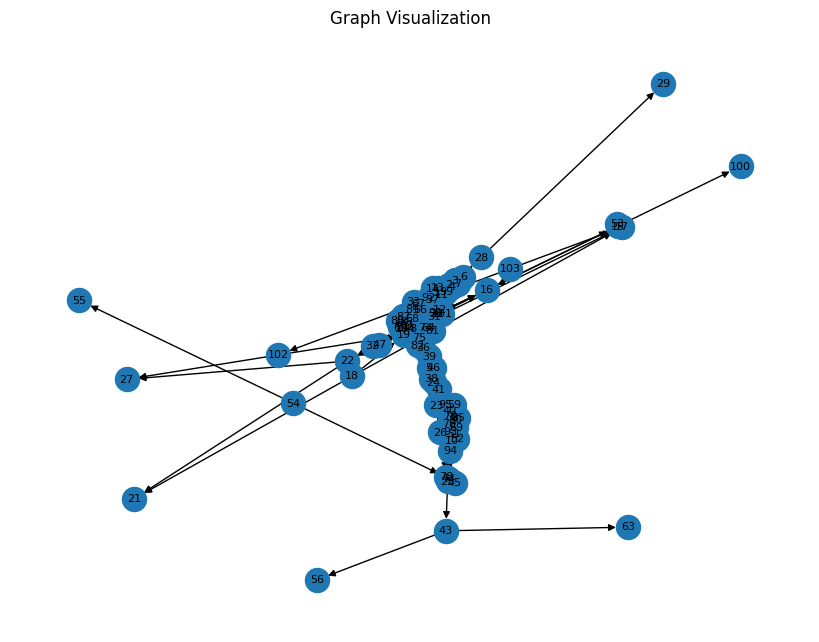

In [2]:
import pickle
import networkx as nx
import matplotlib.pyplot as plt

# -------- LOAD PICKLE GRAPH --------
file_path = "multi_period_routing/gnn_routing_instances/Little_Rock_Arkansas_US/graph.pickle"  # change this

with open(file_path, "rb") as f:
    G = pickle.load(f)

# -------- VERIFY GRAPH --------
if not isinstance(G, nx.Graph):
    raise TypeError("Loaded object is not a NetworkX graph")

print(f"Graph loaded with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")

# -------- DRAW GRAPH --------
plt.figure(figsize=(8, 6))

pos = nx.spring_layout(G, seed=42)  # layout for visualization

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=300,
    font_size=8
)

plt.title("Graph Visualization")
plt.show()